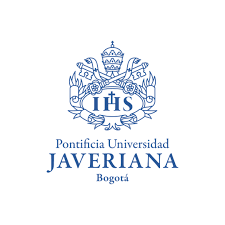

***Pontificia Universidad Javeriana***
# **Procesamiento de Alto Volumen de Datos**

### Taller: **Tratamiento de Datos y Machine Learning con PySpark**

Autor: Jonatan Gallo

Fecha de Inicio: 28/05/2026

Fecha actual: 28/05/2026

## **Problemática**

Se tiene que el tratamiento del agua debe ser indispensable para garantizar la pureza y la calidad. Uno de los elementos significativos es aplicar los conceptos de los Procesamientos de Datos en Alto Volúmen para solucionar este tipo de problemas que afectan la salud publica. El presente ejemplo tiene como propósito tener en cuenta una metodogología para aplicar el PAVD para solucionar o diagnósticar la calidad del agua en la INDIA.

## **Objetivo**

Implementar y comparar múltiples modelos de aprendizaje automático (Keras/TensorFlow, Random Forest, Gradient Boosting y Regresión Lineal) para predecir el **Índice de Calidad del Agua (WQI)** en ríos de la India, evaluando su rendimiento mediante métricas estándar y seleccionando el modelo más adecuado.

## **Metodología**

1. Importación de bibliotecas y levantamiento de sesión Spark sobre el clúster HPC.
2. Carga de datos desde el HDFS del clúster (`hdfs://10.195.34.34:9000/csv/waterquality.csv`).
3. Preprocesamiento: cambio de tipos, análisis de nulos, filtrado y limpieza con PySpark SQL.
4. Análisis Exploratorio de Datos (EDA) y visualización de parámetros.
5. Cálculo del Índice WQI y clasificación de la calidad del agua.
6. Visualización geoespacial sobre el mapa de la India (GeoPandas).
7. Entrenamiento de cuatro modelos: Red Neuronal Keras, MLlib Random Forest, MLlib Gradient Boosted Trees (modelo adicional) y MLlib Regresión Lineal (baseline).
8. Evaluación y comparación con `RegressionEvaluator` de PySpark MLlib.
9. Análisis.
10. conclusiones.

**Referencia de calidad de parámetros del agua:** https://www.intechopen.com/chapters/69568

## **1.- Importación de bibliotecas**
Se importan las dependencias de procesamiento distribuido (PySpark), visualización (Matplotlib, Seaborn), geoespacial (GeoPandas) y aprendizaje profundo (TensorFlow/Keras). No se utiliza scikit-learn; toda la lógica de partición y entrenamiento de modelos clasicos se realiza sobre PySpark MLlib.

### Levantamiento de variables de entorno pip


In [1]:
import os
import sys
import warnings

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
sys.path.append('/usr/lib/python3/dist-packages/')

# Procesamiento numerico y tabular
import numpy as np
import pandas as pd

# Visualizacion
import seaborn as sns
import matplotlib.pyplot as plt
from pylab import *

# PySpark: sesion, SQL y tipos
import findspark
findspark.init()

import pyspark.sql.functions as F
from pyspark import SparkConf, SparkContext
from pyspark.sql import SQLContext
from pyspark.sql import SparkSession
from pyspark.sql.types import *
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression, RandomForestRegressor, GBTRegressor
import pyspark.ml.regression as spark_reg
from pyspark.ml.evaluation import RegressionEvaluator

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Deep Learning (TensorFlow/Keras) — disponible en el entorno del cluster
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Configuración visual
sns.set_theme(style="whitegrid")

warnings.filterwarnings('ignore')
print("Librerías cargadas exitosamente. Versión de TensorFlow:", tf.__version__)

Librerías cargadas exitosamente. Versión de TensorFlow: 2.21.0


In [2]:
import os
print(os.getcwd())

/home/usuario06


### Levantamiento de sesión SPARK
Se crea la sesión Spark conectada al clúster HPC (Master en `spark://10.195.34.34:7077`). La sesión es el punto de entrada para todas las operaciones distribuidas sobre el HDFS.


In [3]:
# Indicar a los workers la ruta correcta de Python en el cluster
os.environ['PYSPARK_PYTHON']        = '/usr/bin/python3'
os.environ['PYSPARK_DRIVER_PYTHON'] = '/usr/bin/python3'

configura = SparkConf()
configura.setAppName("Calidad_Agua_Gallo")

sparkS = SparkSession.builder \
    .config(conf=configura) \
    .config('spark.pyspark.python', '/usr/bin/python3') \
    .getOrCreate()

SQLContext(sparkContext=sparkS.sparkContext, sparkSession=sparkS)
sparkContextoS = sparkS.sparkContext.getOrCreate()

print("Sesion creada: Calidad_Agua_Gallo")
print('Spark version:', sparkS.version)
print('Master URL:', sparkS.sparkContext.master)

#sparkGallo

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/28 14:34:07 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/05/28 14:34:07 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/05/28 14:34:07 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
26/05/28 14:34:07 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.
26/05/28 14:34:07 WARN Utils: Service 'SparkUI' could not bind on port 4043. Attempting port 4044.
26/05/28 14:34:07 WARN Utils: Service 'SparkUI' could not bind on port 4044. Attempting port 4045.
26/05/28 14:34:07 WARN Utils: Service 'SparkUI' could not bind on port 4045. Attempting port 4046.
26/05/28 14:34:07 WARN Utils: Service 'SparkUI' could not bind on port 4046. Attempting port 4047.
26/05/28 14:34:07 WARN Utils: Serv

Sesion creada: Calidad_Agua_Gallo
Spark version: 3.5.5
Master URL: spark://10.195.34.34:7077


## **2.- Carga de Datos desde el HADOOP HDFS**

Los datos se cargan directamente desde el sistema de archivos distribuido Hadoop (HDFS). El archivo `waterquality.csv` contiene mediciones de 534 estaciones a lo largo de los principales ríos de la India.

In [4]:
# Verificar contenido del directorio /csv en HDFS
!/mnt/sda1/Cluster/Hadoop/bin/hadoop fs -ls /csv

Found 11 items
-rw-r--r--   2 sistemas supergroup     977501 2026-03-10 15:27 /csv/CustomerChurn.csv
-rw-r--r--   2 sistemas supergroup      40868 2025-07-07 15:41 /csv/Fortune500USCompanies.csv
drwxr-xr-x   - sistemas supergroup          0 2025-10-16 14:17 /csv/auxiliar
-rw-r--r--   2 sistemas supergroup    4610348 2026-04-28 08:17 /csv/bank-full.csv
-rw-r--r--   2 sistemas supergroup      34635 2025-09-02 13:22 /csv/jugadores.csv
-rw-r--r--   2 sistemas supergroup    1082023 2025-09-02 13:22 /csv/resultados_futbol.csv
-rw-r--r--   2 sistemas supergroup     316971 2025-06-10 09:11 /csv/stroke_pyspark.csv
drwxr-xr-x   - sistemas supergroup          0 2025-06-18 15:36 /csv/taxi
drwxr-xr-x   - sistemas supergroup          0 2026-04-23 15:56 /csv/titanic
-rw-r--r--   2 sistemas supergroup      48036 2025-06-12 14:31 /csv/waterquality.csv
-rw-r--r--   2 sistemas supergroup      84199 2026-04-23 17:11 /csv/winequality-red.csv


In [5]:
# Carga del dataset desde HDFS
DATA_PATH = "../waterquality.csv"

try:
    df00 = sparkS.read.format("csv") \
        .option("header", "true") \
        .load(DATA_PATH)
except:
    df00 = sparkS.read.format("csv") \
        .option("header", "true") \
        .load("hdfs://10.195.34.34:9000/csv/waterquality.csv")

print(f'Registros cargados: {df00.count()}')
print(f'Columnas: {df00.columns}')
df00.show(5)


Registros cargados: 534
Columnas: ['STATION CODE', 'LOCATIONS', 'STATE', 'TEMP', 'DO', 'pH', 'CONDUCTIVITY', 'BOD', 'NITRATE_N_NITRITE_N', 'FECAL_COLIFORM', 'TOTAL_COLIFORM']
+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+--------------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|         735|3.4|                  2|             3|            73|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|  6|  8|         270|3.1|                  2|            72|           182|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|         355|4.2|                  9|            59|           133|
|        2179|GODAVARI RIVER AT...|MAHARASHTRA|24.8|5.5|7

## **3.- Análisis y Preparación de Datos**

Se presentan datos (csv) con los diferentes parámetros de los rios de la India. Cada parámetro es el promedio de los valores medidos en un período de tiempo. Los datos han sido extraidos de la web oficial de la India (RiverIndia)

- Tipos de datos: coherencia de tipo de datos, transformación
- Columnas: conocimiento de las columnas, eliminación.
- Análisis de datos nulos o imposibles: concimiento.
  
**Descripción de columnas:**

- `STATION CODE`: Código de la estación de medición.
- `LOCATIONS`: Ubicación del punto de muestreo en el río.
- `STATE`: Estado de la India donde se ubica la estación.
- `TEMP`: Temperatura del agua en grados Celsius.
- `DO`: Oxígeno Disuelto (mg/L). Concentraciones altas indican mejor calidad.
- `pH`: Logaritmo negativo de la concentración de hidrógeno. Rango óptimo: 6.5–8.5.
- `CONDUCTIVITY`: Capacidad de conducción eléctrica (µS/cm). El agua pura no conduce.
- `BOD`: Demanda Bioquímica de Oxígeno (mg/L). Mayor BOD implica mayor contaminación orgánica.
- `NITRATE_N_NITRITE_N`: Nitratos y nitritos (mg/L). Valores altos estimulan crecimiento de algas.
- `FECAL_COLIFORM`: Bacterias coliformes fecales (UFC/100mL). Indicador de contaminación microbiológica.
- `TOTAL_COLIFORM`: Se eliminará pues no aporta al estudio de predicción de la calidad del agua.

In [6]:
##Conocimiento de las columnas
df00.columns

['STATION CODE',
 'LOCATIONS',
 'STATE',
 'TEMP',
 'DO',
 'pH',
 'CONDUCTIVITY',
 'BOD',
 'NITRATE_N_NITRITE_N',
 'FECAL_COLIFORM',
 'TOTAL_COLIFORM']

**Se presenta las estadísticas de los datos a continuación:**

In [7]:
# Conocimiento de columnas y estadísticas descriptivas por parámetro
print('Columnas del dataset:')
print(df00.columns)
print()

for col in df00.columns:
    df00.describe([col]).show()

Columnas del dataset:
['STATION CODE', 'LOCATIONS', 'STATE', 'TEMP', 'DO', 'pH', 'CONDUCTIVITY', 'BOD', 'NITRATE_N_NITRITE_N', 'FECAL_COLIFORM', 'TOTAL_COLIFORM']



+-------+-----------------+
|summary|     STATION CODE|
+-------+-----------------+
|  count|              534|
|   mean|2052.516853932584|
| stddev|755.2178560086894|
|    min|             1023|
|    max|               41|
+-------+-----------------+

+-------+-------------------+
|summary|          LOCATIONS|
+-------+-------------------+
|  count|                534|
|   mean|               NULL|
| stddev|               NULL|
|    min|          AHMEDABAD|
|    max|ZUARI AT PANCHAWADI|
+-------+-------------------+



+-------+--------------+
|summary|         STATE|
+-------+--------------+
|  count|           534|
|   mean|          NULL|
| stddev|          NULL|
|    min|ANDHRA PRADESH|
|    max|   WEST BENGAL|
+-------+--------------+

+-------+------------------+
|summary|              TEMP|
+-------+------------------+
|  count|               534|
|   mean|25.241398865784515|
| stddev|3.4480130875026624|
|    min|              10.5|
|    max|                NA|
+-------+------------------+

+-------+-----------------+
|summary|               DO|
+-------+-----------------+
|  count|              534|
|   mean|6.389812030075193|
| stddev|1.622861728733986|
|    min|                0|
|    max|               NA|
+-------+-----------------+

+-------+------------------+
|summary|                pH|
+-------+------------------+
|  count|               534|
|   mean|  7.79812734082397|
| stddev|0.6499503911518124|
|    min|              13.2|
|    max|               9.1|
+-------+------------------

## Visualización de Datos Nulos

Se identifican los valores nulos o no definidos en cada columna para determinar la estrategia de imputación. PySpark distingue entre `null` e `isnan`, por lo que se evalúan ambas condiciones.

In [8]:
#Cantidad de Valores Nulos o Imposibles
df00.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df00.columns]).show()

print('Columnas con valores nulos se imputaran con la mediana en el paso de limpieza.')

+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|LOCATIONS|STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|           0|        0|    0|   0|  0|  0|           0|  0|                  0|             0|             0|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+

Columnas con valores nulos se imputaran con la mediana en el paso de limpieza.


* Se observa que no hay datos nulos o imposibles
* Se procede a Graficar cada una de las dimensiones
* #Se crea una vista para ser usada en las visualizaciones

In [9]:
# Crear vista SQL para consultas posteriores
df00.createOrReplaceTempView('df00_sql')

# Filtrar solo registros completos en las columnas de interes para el analisis exploratorio
df01 = sparkS.sql('''
    SELECT * FROM df00_sql
    WHERE TEMP              IS NOT NULL
      AND DO                IS NOT NULL
      AND pH                IS NOT NULL
      AND CONDUCTIVITY      IS NOT NULL
      AND BOD               IS NOT NULL
      AND NITRATE_N_NITRITE_N IS NOT NULL
      AND FECAL_COLIFORM    IS NOT NULL
''')

print(f'Registros tras filtrar nulos: {df01.count()}')

Registros tras filtrar nulos: 534


#### Se verifica la Cantidad de Valores Nulos o Imposibles

In [10]:
df01.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df01.columns]).show()

+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|STATION CODE|LOCATIONS|STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|TOTAL_COLIFORM|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+
|           0|        0|    0|   0|  0|  0|           0|  0|                  0|             0|             0|
+------------+---------+-----+----+---+---+------------+---+-------------------+--------------+--------------+



### Tratamiento de datos

Se transforman las columnas numéricas de tipo `string` (resultado de la carga CSV) al tipo `FloatType` de PySpark, lo cual es necesario para que las operaciones aritméticas y los modelos MLlib funcionen correctamente. Adicionalmente se elimina la columna `TOTAL_COLIFORM`.

In [11]:
# Verificar tipos de datos antes de la transformacion
print('Tipos antes de transformacion:')
print(df00.dtypes)
print()

##Se procede a cambiar los tipos de datos
df00 = df00.withColumn('TEMP', df00['TEMP'].cast(FloatType()))
df00 = df00.withColumn('pH', df00['pH'].cast(FloatType()))
df00 = df00.withColumn('DO', df00['DO'].cast(FloatType()))
df00 = df00.withColumn('CONDUCTIVITY', df00['CONDUCTIVITY'].cast(FloatType()))
df00 = df00.withColumn('NITRATE_N_NITRITE_N', df00['NITRATE_N_NITRITE_N'].cast(FloatType()))
df00 = df00.withColumn('FECAL_COLIFORM', df00['FECAL_COLIFORM'].cast(FloatType()))
df00 = df00.withColumn('BOD', df00['BOD'].cast(FloatType()))
df00.dtypes

print('Tipos despues de transformacion:')
print(df00.dtypes)

Tipos antes de transformacion:
[('STATION CODE', 'string'), ('LOCATIONS', 'string'), ('STATE', 'string'), ('TEMP', 'string'), ('DO', 'string'), ('pH', 'string'), ('CONDUCTIVITY', 'string'), ('BOD', 'string'), ('NITRATE_N_NITRITE_N', 'string'), ('FECAL_COLIFORM', 'string'), ('TOTAL_COLIFORM', 'string')]

Tipos despues de transformacion:
[('STATION CODE', 'string'), ('LOCATIONS', 'string'), ('STATE', 'string'), ('TEMP', 'float'), ('DO', 'float'), ('pH', 'float'), ('CONDUCTIVITY', 'float'), ('BOD', 'float'), ('NITRATE_N_NITRITE_N', 'float'), ('FECAL_COLIFORM', 'float'), ('TOTAL_COLIFORM', 'string')]


In [12]:
# Eliminar TOTAL_COLIFORM (no utilizada en el calculo del WQI)
df01 = df00.drop('TOTAL_COLIFORM')
print('Columnas tras eliminar TOTAL_COLIFORM:')
print(df01.columns)

Columnas tras eliminar TOTAL_COLIFORM:
['STATION CODE', 'LOCATIONS', 'STATE', 'TEMP', 'DO', 'pH', 'CONDUCTIVITY', 'BOD', 'NITRATE_N_NITRITE_N', 'FECAL_COLIFORM']


## 4. Creación de Tablas para Visualizar los Datos

Se utiliza la función lambda sobre el RDD para extraer cada parámetro como una lista de Python y construir los gráficos de series temporales. Este patrón es el indicado por el cuaderno base del taller.

In [13]:
# Crear vista SQL del dataframe limpio
df01.createOrReplaceTempView('df01_sql')

# Extraccion de cada parametro como lista mediante lambda sobre RDD
do_parametro   = sparkS.sql('SELECT DO   FROM df01_sql').rdd.map(lambda f: f.DO).collect()
ph_parametro   = sparkS.sql('SELECT pH   FROM df01_sql').rdd.map(lambda f: f.pH).collect()
BOD_parametro  = sparkS.sql('SELECT BOD  FROM df01_sql').rdd.map(lambda f: f.BOD).collect()
NN_parametro   = sparkS.sql('SELECT NITRATE_N_NITRITE_N FROM df01_sql').rdd.map(lambda f: f.NITRATE_N_NITRITE_N).collect()
COND_parametro = sparkS.sql('SELECT CONDUCTIVITY FROM df01_sql').rdd.map(lambda f: f.CONDUCTIVITY).collect()
FC_parametro   = sparkS.sql('SELECT FECAL_COLIFORM FROM df01_sql').rdd.map(lambda f: f.FECAL_COLIFORM).collect()

print(f'Registros por parametro: {len(do_parametro)}')


Registros por parametro: 534


#### Grafica Los parámetros para conocer sus características: DO y PH

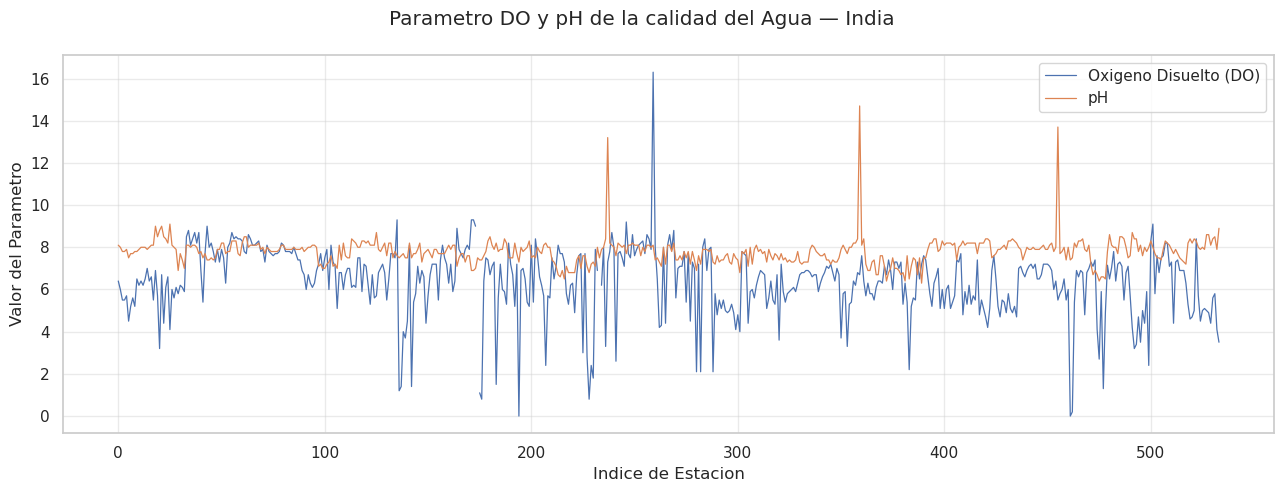

In [14]:
# Grafica 1: Parametros DO y pH por estacion de medicion
tam = len(do_parametro)
fig, ax1 = plt.subplots(figsize=(13, 5), facecolor='w', edgecolor='k')
ax1.plot(range(tam), do_parametro, label='Oxigeno Disuelto (DO)', linewidth=0.9)
ax1.plot(range(tam), ph_parametro, label='pH', linewidth=0.9)
fig.suptitle('Parametro DO y pH de la calidad del Agua — India')
ax1.set_xlabel('Indice de Estacion')
ax1.set_ylabel('Valor del Parametro')
ax1.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


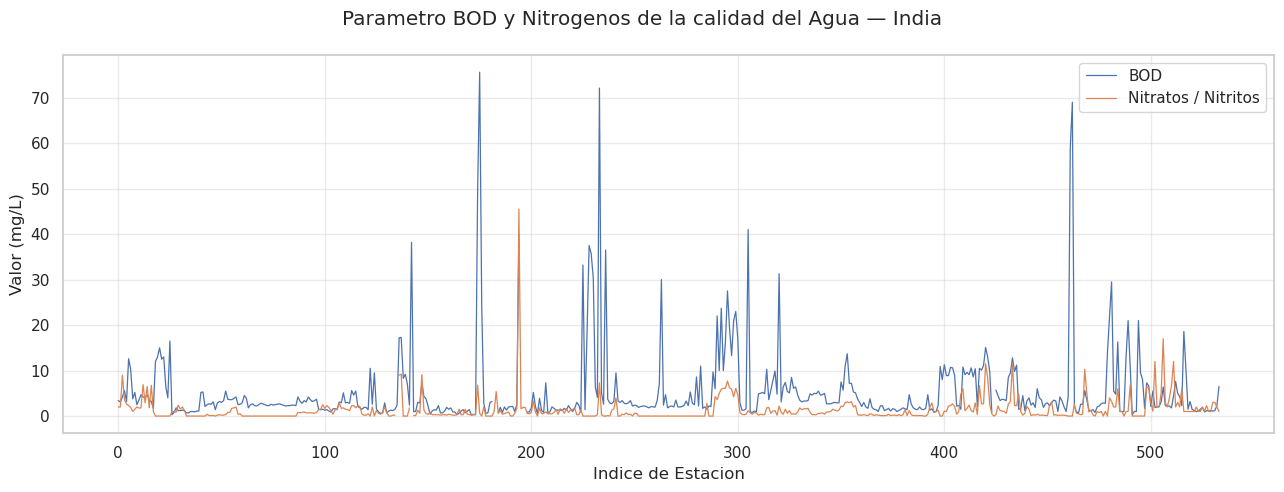

In [15]:
# Grafica 2: Parametros BOD y Nitratos/Nitritos
fig, ax2 = plt.subplots(figsize=(13, 5), facecolor='w', edgecolor='k')
ax2.plot(range(tam), BOD_parametro, label='BOD', linewidth=0.9)
ax2.plot(range(tam), NN_parametro,  label='Nitratos / Nitritos', linewidth=0.9)
fig.suptitle('Parametro BOD y Nitrogenos de la calidad del Agua — India')
ax2.set_xlabel('Indice de Estacion')
ax2.set_ylabel('Valor (mg/L)')
ax2.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

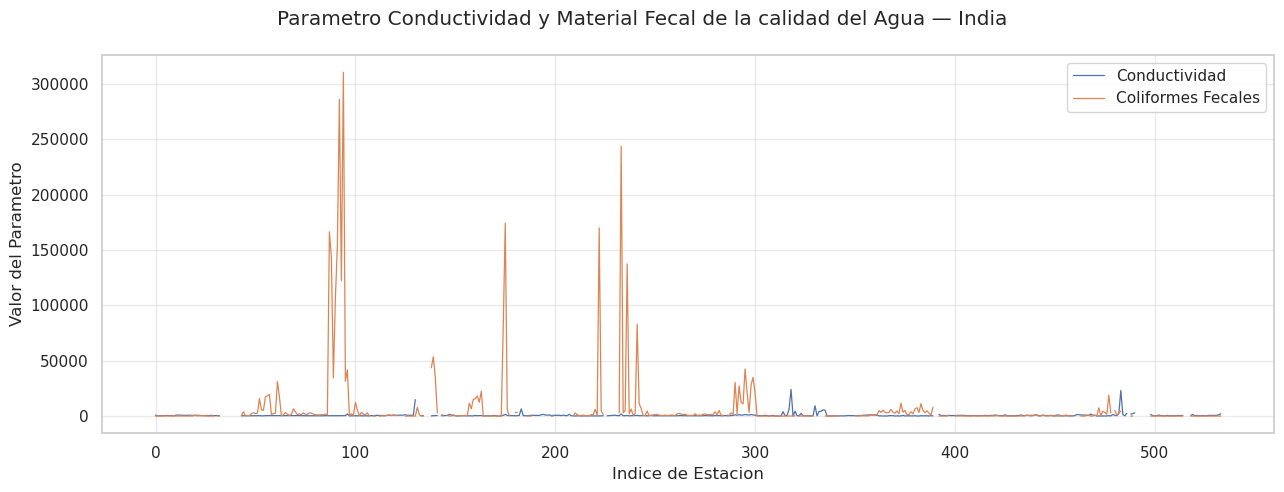

Apreciacion: FECAL_COLIFORM presenta valores extremos (hasta 310,000 UFC/100mL) indicativos de contaminacion microbiologica severa en algunas estaciones.


In [16]:
# Grafica 3: Conductividad y Material Fecal
fig, ax3 = plt.subplots(figsize=(13, 5), facecolor='w', edgecolor='k')
ax3.plot(range(tam), COND_parametro, label='Conductividad', linewidth=0.9)
ax3.plot(range(tam), FC_parametro,   label='Coliformes Fecales', linewidth=0.9)
fig.suptitle('Parametro Conductividad y Material Fecal de la calidad del Agua — India')
ax3.set_xlabel('Indice de Estacion')
ax3.set_ylabel('Valor del Parametro')
ax3.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print('Apreciacion: FECAL_COLIFORM presenta valores extremos (hasta 310,000 UFC/100mL)'
      ' indicativos de contaminacion microbiologica severa en algunas estaciones.')

## 5. Calculo del Índice de Calidad del Agua (WQI)

### 5.1 Funciones de rango por parametro

Cada parámetro recibe un puntaje discreto (0, 40, 60, 80 o 100) según los intervalos establecidos en la referencia bibliográfica (Según https://www.intechopen.com/chapters/69568). Las funciones se implementan mediante columnas condicionales `F.when` de PySpark.

| Puntaje | Interpretacion |
|---------|----------------|
| 100     | Optimo / Agua dulce |
| 80      | Moderada |
| 60      | Dura |
| 40      | Muy dura |
| 0       | Inadecuada |


In [17]:
# Rango de calidad segun pH (optimo: 7.0 – 8.5)
df02 = df01.withColumn('qrPH',
    F.when((df01.pH >= 7.0) & (df01.pH <= 8.5), 100)
    .when(((df01.pH >= 6.8) & (df01.pH < 7.0))  | ((df01.pH > 8.5)  & (df01.pH < 8.6)),  80)
    .when(((df01.pH >= 6.7) & (df01.pH < 6.8))  | ((df01.pH >= 8.6) & (df01.pH < 8.8)),  60)
    .when(((df01.pH >= 6.5) & (df01.pH < 6.7))  | ((df01.pH >= 8.8) & (df01.pH < 9.0)),  40)
    .otherwise(0)
)

# Rango de calidad segun DO (mayor valor = mejor calidad)
df02 = df02.withColumn('qrDO',
    F.when(df02.DO >= 6.0, 100)
    .when((df02.DO >= 5.1) & (df02.DO < 6.0), 80)
    .when((df02.DO >= 4.1) & (df02.DO < 5.0), 60)
    .when((df02.DO >= 3.0) & (df02.DO <= 4.0), 40)
    .otherwise(0)
)

# Rango de calidad segun CONDUCTIVITY
df02 = df02.withColumn('qrCOND',
    F.when((df02.CONDUCTIVITY >= 0.0)   & (df02.CONDUCTIVITY <= 75.0),  100)
    .when((df02.CONDUCTIVITY > 75.0)  & (df02.CONDUCTIVITY <= 150.0),  80)
    .when((df02.CONDUCTIVITY > 150.0) & (df02.CONDUCTIVITY <= 225.0),  60)
    .when((df02.CONDUCTIVITY > 225.0) & (df02.CONDUCTIVITY <= 300.0),  40)
    .otherwise(0)
)

# Rango de calidad segun BOD (mayor BOD = mayor contaminacion organica)
df02 = df02.withColumn('qrBOD',
    F.when((df02.BOD >= 0.0)  & (df02.BOD < 3.0),   100)
    .when((df02.BOD >= 3.0)  & (df02.BOD < 6.0),    80)
    .when((df02.BOD >= 6.0)  & (df02.BOD < 80.0),   60)
    .when((df02.BOD >= 80.0) & (df02.BOD < 125.0),  40)
    .otherwise(0)
)

# Rango de calidad segun NITRATE_N_NITRITE_N
df02 = df02.withColumn('qrNN',
    F.when((df02.NITRATE_N_NITRITE_N >= 0.0)   & (df02.NITRATE_N_NITRITE_N < 20.0),   100)
    .when((df02.NITRATE_N_NITRITE_N >= 20.0)  & (df02.NITRATE_N_NITRITE_N < 50.0),   80)
    .when((df02.NITRATE_N_NITRITE_N >= 50.0)  & (df02.NITRATE_N_NITRITE_N < 100.0),  60)
    .when((df02.NITRATE_N_NITRITE_N >= 100.0) & (df02.NITRATE_N_NITRITE_N < 200.0),  40)
    .otherwise(0)
)

# Rango de calidad segun FECAL_COLIFORM (indicador microbiologico directo)
df02 = df02.withColumn('qrFecal',
    F.when((df02.FECAL_COLIFORM >= 0.0)   & (df02.FECAL_COLIFORM < 5.0),     100)
    .when((df02.FECAL_COLIFORM >= 5.0)   & (df02.FECAL_COLIFORM < 50.0),    80)
    .when((df02.FECAL_COLIFORM >= 50.0)  & (df02.FECAL_COLIFORM < 500.0),   60)
    .when((df02.FECAL_COLIFORM >= 500.0) & (df02.FECAL_COLIFORM < 1000.0),  40)
    .otherwise(0)
)

print('Rangos de calidad calculados. Inspeccion de df02:')
df02.show(10)
print('Columnas:', df02.columns)


Rangos de calidad calculados. Inspeccion de df02:
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|       355.0| 4.2|                9.0|          59.0| 100|  80|     0|   80| 100|     60|
|        2179|GODAVARI RIVER AT...|MAHARASHTRA|24.

### 5.2 Indices ponderados y calculo del WQI

Cada rango se multiplica por el peso asignado en la referencia bibliográfica. El WQI es la suma de los seis índices ponderados.

| Parametro        | Peso  |
|------------------|-------|
| pH               | 0.165 |
| DO               | 0.281 |
| CONDUCTIVITY     | 0.234 |
| BOD              | 0.009 |
| NITRATE+NITRITE  | 0.028 |
| FECAL COLIFORM   | 0.281 |

**Nota:** Segun la literatura, el numero de datos disponibles es reducido para que el WQI refleje un valor estadisticamente confiable a nivel nacional. El presente ejercicio tiene caracter metodologico academico.


#### **Creación de columnas que contengan el Índice de Calidad según la refencia bibliográfica**

In [18]:
# Indices ponderados por parametro
df03 = df02.withColumn('wpH',    F.round(df02.qrPH    * 0.165, 3))
df03 = df03.withColumn('wDO',    F.round(df03.qrDO    * 0.281, 3))
df03 = df03.withColumn('wCOND',  F.round(df03.qrCOND  * 0.234, 3))
df03 = df03.withColumn('wBOD',   F.round(df03.qrBOD   * 0.009, 3))
df03 = df03.withColumn('wNN',    F.round(df03.qrNN    * 0.028, 3))
df03 = df03.withColumn('wFecal', F.round(df03.qrFecal * 0.281, 3))

df03.show(10)
print('Columnas de df03:', df03.columns)


+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5|7.8|       355.0| 4.2|       

#### **Calculo del Índice de Calidad del Agua**
- Se crea la columna WQI: representa el índice de calidad, pero la NOTA A RESALTAR es que según la literatura, son muy pocos datos para que refleje un valor confiable. Es decir, que como un estudio ejemplo, NO ES UNA GUIA A TENER EN CUENTA PARA CALIDAD DE AGUA

In [19]:
# WQI: suma de los seis indices ponderados
df04 = df03.withColumn(
    'WQI',
    F.round(df03.wpH + df03.wBOD + df03.wCOND + df03.wNN + df03.wFecal + df03.wDO, 3)
)
df04.show(10)

+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|
|        2182|GODAVARI RIVER AT...|MAHARASHTRA|25.8|5.5

### 5.3 Clasificacion de la calidad del agua

Se asigna una etiqueta categorica al WQI segun los intervalos de la referencia:

- **Excelente**: Agua dulce — ***WQI en [0.0, 25.0)***
- **Buena**: Agua moderada — ***WQI en [25.0, 50.0)***
- **Baja**: Agua dura — ***WQI en [50.0, 75.0)***
- **Muy_Baja**: Agua muy dura — ***WQI en [75.0, 100.0)***
- **Inadecuada**: Agua residual — ***WQI >= 100***


In [20]:
df05 = df04.withColumn('CALIDAD',
    F.when((df04.WQI >= 0)  & (df04.WQI < 25),  'Excelente')
    .when((df04.WQI >= 25) & (df04.WQI < 50),  'Buena')
    .when((df04.WQI >= 50) & (df04.WQI < 75),  'Baja')
    .when((df04.WQI >= 75) & (df04.WQI < 100), 'Muy_Baja')
    .otherwise('Inadecuada')
)

df05.show(10)

# Distribucion de la calidad del agua
print('Distribucion de categorias de calidad:')
df05.groupBy('CALIDAD').count().orderBy('count', ascending=False).show()


+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY| BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI| CALIDAD|
+------------+--------------------+-----------+----+---+---+------------+----+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|        1312|GODAVARI AT JAYAK...|MAHARASHTRA|29.2|6.4|8.1|       735.0| 3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|Muy_Baja|
|        2177|GODAVARI RIVER NE...|MAHARASHTRA|24.5|6.0|8.0|       270.0| 3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|    Baja|
|        2

## 6. Visualización Geoespacial de la India

Se carga el shapefile de los estados de la India y se cruza con los datos del WQI calculado en Spark. La combinacion se realiza en formato Pandas (vía `toPandas()`) para ser procesada por GeoPandas.

- Se visualizan los estados sobre los datos obtenidos de la Calidad del Agua, es decir, las etiquetas de calidad de agua

In [21]:
# Inspeccion de nombres de estados unicos en el dataframe Spark
colEstado = 'STATE'
valNombres = df05.select(colEstado).distinct().collect()
valNombres = [v[colEstado] for v in valNombres]
print('Estados en el dataset:', valNombres)

Estados en el dataset: ['WEST BENGAL', 'GOA', 'CHHATTISGARH', 'RAJASTHAN', 'DELHI', 'HIMACHAL PRADESH', 'GUJARAT', 'BIHAR', 'KARNATAKA', 'UTTAR PRADESH', 'MADHYA PRADESH', 'MAHARASHTRA', 'PUNJAB', 'UTTARAKHAND', 'TAMILNADU', 'ANDHRA PRADESH', 'KERALA', 'ASSAM']


#### **Se cargan los datos de los mapas disponibles**
- Los ficheros comprimidos "dbf", "prj", "shp", "shx" deben estar juntos en una carpeta

In [22]:
import geopandas as gpd

# Ruta al shapefile en el sistema de archivos local del nodo maestro
rutaMapas = 'Indian_States.shp'

# Se carga un objeto dataframe de los datos comprimidos de los mapas
gpd01 = gpd.read_file(rutaMapas)

# Se visualiza el tipo de dataframe que da geopandas y las columnas 
print('Tipo:', type(gpd01))
print('Columnas del GeoDataFrame:', gpd01.columns.tolist())

#Se visualizan los nombres de la columna de los estados "st_nm"
print('Estados en shapefile:', gpd01['st_nm'].unique())


Tipo: <class 'geopandas.geodataframe.GeoDataFrame'>
Columnas del GeoDataFrame: ['st_nm', 'geometry']
Estados en shapefile: ['Andaman & Nicobar Island' 'Arunanchal Pradesh' 'Assam' 'Bihar'
 'Chandigarh' 'Chhattisgarh' 'Dadara & Nagar Havelli' 'Daman & Diu' 'Goa'
 'Gujarat' 'Haryana' 'Himachal Pradesh' 'Jammu & Kashmir' 'Jharkhand'
 'Karnataka' 'Kerala' 'Lakshadweep' 'Madhya Pradesh' 'Maharashtra'
 'Manipur' 'Meghalaya' 'Mizoram' 'Nagaland' 'NCT of Delhi' 'Puducherry'
 'Punjab' 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana' 'Tripura'
 'Uttar Pradesh' 'Uttarakhand' 'West Bengal' 'Odisha' 'Andhra Pradesh']


#### Se procede a eliminar caracteres irregulares: la idea es que los estados del mapa coincidan con los nombres de los estados del dataframe de datos inicial


In [23]:
# Normalizar nombres de estados: eliminar caracteres especiales (&)
# para garantizar coincidencia con los nombres del dataset CSV
gpd02 = gpd01.replace({
    'Andaman & Nicobar Island': 'Andaman Nicobar Island',
    'Dadara & Nagar Havelli'  : 'Dadara Nagar Havelli',
    'Daman & Diu'             : 'Daman Diu',
    'Jammu & Kashmir'         : 'Jammu Kashmir',
    'NCT of Delhi'            : 'Delhi'
})
print('Nombres normalizados:', gpd02['st_nm'].unique())


Nombres normalizados: ['Andaman Nicobar Island' 'Arunanchal Pradesh' 'Assam' 'Bihar'
 'Chandigarh' 'Chhattisgarh' 'Dadara Nagar Havelli' 'Daman Diu' 'Goa'
 'Gujarat' 'Haryana' 'Himachal Pradesh' 'Jammu Kashmir' 'Jharkhand'
 'Karnataka' 'Kerala' 'Lakshadweep' 'Madhya Pradesh' 'Maharashtra'
 'Manipur' 'Meghalaya' 'Mizoram' 'Nagaland' 'Delhi' 'Puducherry' 'Punjab'
 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana' 'Tripura' 'Uttar Pradesh'
 'Uttarakhand' 'West Bengal' 'Odisha' 'Andhra Pradesh']


Se hacen los cambios correspondientes, a continuación, para que coincidan con los nombres iniciales
- nombre de "st_nm" que sea "STATE"
- Se combinan es formato pandas para pintar el mapa
- Se garantizan los puntos dentro del mapa
- Se eliminan los duplicados

In [24]:
#Nombre de "Tamil Nadu" se cambia a "TAMILNADU" en objeto dataframe spark
df06 = df05.withColumn('STATE', F.regexp_replace('STATE', 'TAMILNADU', 'TAMIL NADU'))

#Se deja todo en letra Capital en el df spark
df06 = df06.withColumn('STATE', F.initcap('STATE'))

#Inspección ocular del cambio
df06.show(5)

+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|STATION CODE|           LOCATIONS|      STATE|TEMP| DO| pH|CONDUCTIVITY|BOD|NITRATE_N_NITRITE_N|FECAL_COLIFORM|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal| wpH|  wDO|wCOND|wBOD|wNN|wFecal|  WQI| CALIDAD|
+------------+--------------------+-----------+----+---+---+------------+---+-------------------+--------------+----+----+------+-----+----+-------+----+-----+-----+----+---+------+-----+--------+
|        1312|GODAVARI AT JAYAK...|Maharashtra|29.2|6.4|8.1|       735.0|3.4|                2.0|           3.0| 100| 100|     0|   80| 100|    100|16.5| 28.1|  0.0|0.72|2.8|  28.1|76.22|Muy_Baja|
|        2177|GODAVARI RIVER NE...|Maharashtra|24.5|6.0|8.0|       270.0|3.1|                2.0|          72.0| 100| 100|    40|   80| 100|     60|16.5| 28.1| 9.36|0.72|2.8| 16.86|74.34|    Baja|
|        2182|G

In [25]:
#Se cambia el nombre en el gpd de la columna "st_nm" a "STATE"
gpd03 = gpd02.rename(columns= {"st_nm": "STATE"})

#Se combinan los nombres entre los dos objetos dataframe: map y spark, con la clave "STATE"
dfMAP = pd.merge(gpd03, df06.toPandas(), how='outer', on='STATE')

#Se toman los puntos a bajo coste que garantizan estar dentro de la geometria (mapa)
dfMAP['coords'] = dfMAP['geometry'].apply(lambda x: x.representative_point().coords[:])
dfMAP['coords'] = [coords[0] for coords in dfMAP['coords']]

#Se eliminan los puntos duplicados
dfMAP = dfMAP.drop_duplicates(subset="STATE")

print(f'Estados en el mapa combinado: {dfMAP.shape[0]}')

Estados en el mapa combinado: 36


#### **Se pinta el mapa inicial**

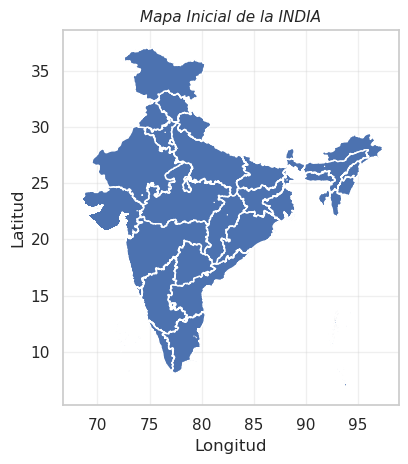

In [26]:
# Mapa inicial de la India
dfMAP.plot(missing_kwds={'color': 'lightgrey'})
plt.title('Mapa Inicial de la INDIA', fontsize=11, style='italic')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### *Se requiere superponer las etiquetas de los estados de la India en el MAPA*

In [27]:
import subprocess

# Instalar en el directorio del usuario para que el kernel lo encuenta
subprocess.run([
    sys.executable, '-m', 'pip', 'install',
    'adjustText', 'mapclassify>=2.4.0',
    '--user', '-q'
], check=True)

# Agregar la ruta de instalacion del usuario al path del kernel
import site
if site.getusersitepackages() not in sys.path:
    sys.path.append(site.getusersitepackages())

from adjustText import adjust_text
print('adjustText importado correctamente.')

adjustText importado correctamente.


In [28]:
# Instalacion de bibliotecas auxiliares para el mapa (si no estan disponibles)
!{sys.executable} -m pip install 'mapclassify>=2.4.0' --break-system-packages -q

from adjustText import adjust_text #Para evitar que se supermonten las etiquetas

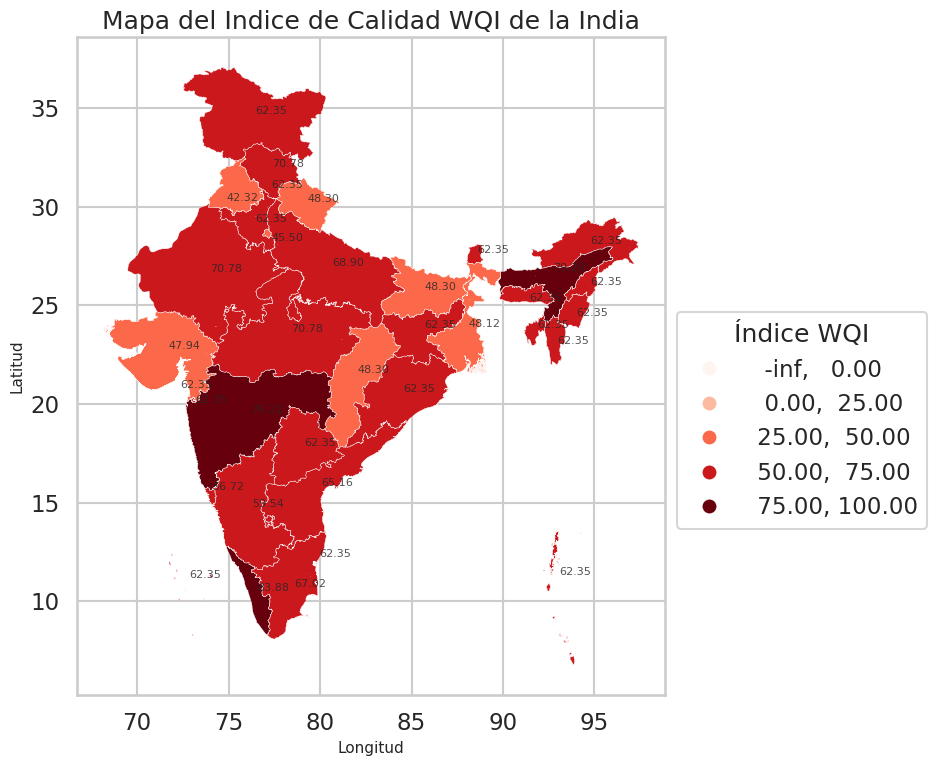

In [29]:
#Se verifica los valores NULOS; en caso de que existan se cambian por el promedio
#Se toma la ruta corta (la imputación de valores nulos puede ser mejor tratada)
dfMAP['WQI'] = dfMAP['WQI'].fillna(dfMAP['WQI'].median())

## Configuración de Estilos para ser usados en la impresión con seaborn
sns.set_context("talk") #puede ser cualquiera
sns.set_style("whitegrid") #Puede ser cualquiera de la biblioteca de estilos de seaborn

#Se ajusta el mapa 
fig, ax = plt.subplots(figsize = (12,8))
#dibujar el mapa
dfMAP.plot(column='WQI', cmap='Reds', ax=ax, scheme='userdefined',
          classification_kwds={'bins': [0,25,50,75,100]},
          legend=True, linewidth = 0.3)

##Ajustar la leyenda
leg = ax.get_legend()
leg.set_title('Índice WQI')
leg.set_bbox_to_anchor((1,0.6))

## Se agregan las etiquetas sin superposición (tener cuidado con el tamaño del PLOT)
textos = []
for _, row in dfMAP.iterrows():
    if not np.isnan(row['WQI']):
        centroide = row.geometry.centroid
        texto = ax.annotate(f"{row['WQI']:.2f}", xy=(centroide.x, centroide.y),
                           fontsize=8, alpha=0.8)
        textos.append(texto)
    
#Ajustar texto de etiquetas
adjust_text(textos, ax=ax, force_points=(0.2, 0.2))

### CARPINTERIA
ax.set_title("Mapa del Indice de Calidad WQI de la India")
ax.set_xlabel("Longitud", fontsize=11)
ax.set_ylabel("Latitud", fontsize=11)
plt.tight_layout()
plt.show()

#### **Histograma de WQI por Estado**

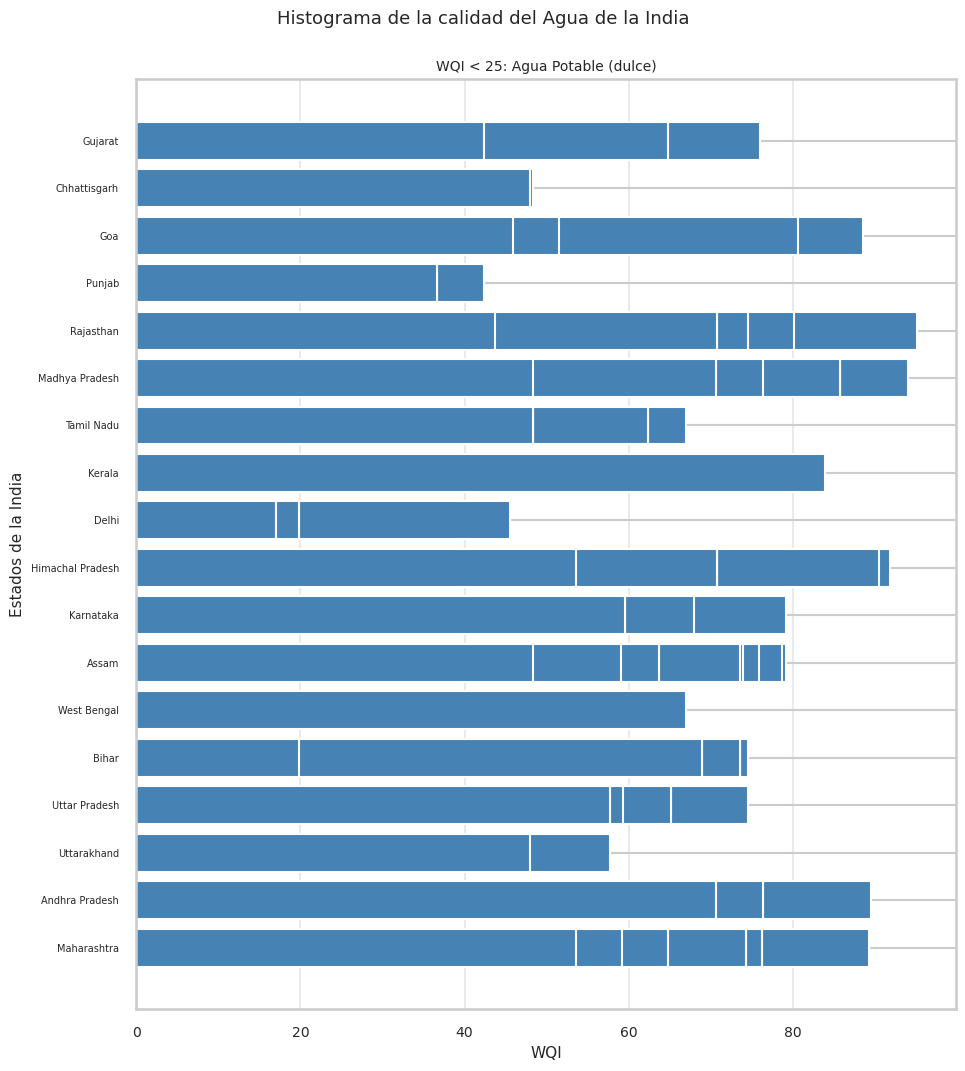

In [30]:
df06.createOrReplaceTempView("df06_sql")
#Se seleccionan los nombres de los estados
estados_spark = sparkS.sql('SELECT STATE FROM df06_sql')
estados_lista  = estados_spark.rdd.map(lambda row: row.STATE).collect()

## Seleccionamos los valores de WQI
wqi_spark = sparkS.sql('SELECT WQI FROM df06_sql')
wqi_lista  = wqi_spark.rdd.map(lambda row: row.WQI).collect()

##Se grafica el histograma
plt.figure(figsize=(10, 11))
plt.barh(estados_lista, wqi_lista, color='steelblue', edgecolor='white')
plt.suptitle('Histograma de la calidad del Agua de la India', fontsize=13)
plt.title('WQI < 25: Agua Potable (dulce)', fontsize=10)
plt.xlabel('WQI', fontsize=11)
plt.ylabel('Estados de la India', fontsize=11)
plt.xticks(fontsize=10)
plt.yticks(fontsize=7)
plt.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.show()

## 7. Creacion de Modelos de Machine Learning

Se entrenan cuatro modelos para predecir el WQI. Los tres primeros se implementan sobre **PySpark MLlib** (sin necesidad de sklearn), por lo que pueden escalar de forma nativa sobre el clúster. El cuarto modelo (Red Neuronal) se implementa con **TensorFlow/Keras**, alimentado con datos convertidos a NumPy desde el DataFrame Spark.

| Modelo | Implementacion | Tipo |
|---|---|---|
| Red Neuronal Keras | TensorFlow/Keras | Regresion |
| Random Forest | PySpark MLlib | Regresion |
| Gradient Boosted Trees | PySpark MLlib | Regresion (adicional) |
| Regresion Lineal | PySpark MLlib | Baseline |

**Variable objetivo:** `WQI`  
**Caracteristicas (features):** `qrPH`, `qrDO`, `qrCOND`, `qrBOD`, `qrNN`, `qrFecal`

In [31]:
# Seleccionar columnas de interes para el entrenamiento
print('Columnas disponibles en df06:')
print(df06.columns)

Columnas disponibles en df06:
['STATION CODE', 'LOCATIONS', 'STATE', 'TEMP', 'DO', 'pH', 'CONDUCTIVITY', 'BOD', 'NITRATE_N_NITRITE_N', 'FECAL_COLIFORM', 'qrPH', 'qrDO', 'qrCOND', 'qrBOD', 'qrNN', 'qrFecal', 'wpH', 'wDO', 'wCOND', 'wBOD', 'wNN', 'wFecal', 'WQI', 'CALIDAD']


In [32]:
# Dataframe con features y target
df_features = df06.select('qrPH','qrDO','qrCOND','qrBOD','qrNN','qrFecal','WQI')
df_features.show(5)

+----+----+------+-----+----+-------+-----+
|qrPH|qrDO|qrCOND|qrBOD|qrNN|qrFecal|  WQI|
+----+----+------+-----+----+-------+-----+
| 100| 100|     0|   80| 100|    100|76.22|
| 100| 100|    40|   80| 100|     60|74.34|
| 100|  80|     0|   80| 100|     60|59.36|
| 100|  80|     0|   80| 100|     60|59.36|
| 100|  80|    40|   80| 100|     80|74.34|
+----+----+------+-----+----+-------+-----+
only showing top 5 rows



### 7.1 Preparacion del vector de caracteristicas con VectorAssembler

`VectorAssembler` es el componente de PySpark MLlib que combina multiples columnas en una unica columna de tipo `Vector`, formato requerido por todos los modelos MLlib.

In [33]:
# Lista de columnas de entrada al modelo
cols_features = ['qrPH', 'qrDO', 'qrCOND', 'qrBOD', 'qrNN', 'qrFecal']

# VectorAssembler: combina las columnas de features en un vector unico
assembler = VectorAssembler(
    inputCols=cols_features,
    outputCol='features'
)

# Transformar el dataframe para agregar la columna 'features'
df_ml = assembler.transform(df_features).select('features', 'WQI')
df_ml.show(5, truncate=False)

print(f'Total de registros: {df_ml.count()}')


+----------------------------------+-----+
|features                          |WQI  |
+----------------------------------+-----+
|[100.0,100.0,0.0,80.0,100.0,100.0]|76.22|
|[100.0,100.0,40.0,80.0,100.0,60.0]|74.34|
|[100.0,80.0,0.0,80.0,100.0,60.0]  |59.36|
|[100.0,80.0,0.0,80.0,100.0,60.0]  |59.36|
|[100.0,80.0,40.0,80.0,100.0,80.0] |74.34|
+----------------------------------+-----+
only showing top 5 rows

Total de registros: 534


In [34]:
# División aleatoria con semilla para reproducibilidad
train_data, test_data = df_ml.randomSplit([0.8, 0.2], seed=42)

print(f"Registros de entrenamiento: {train_data.count()}")
print(f"Registros de prueba: {test_data.count()}")

[Stage 72:>                                                         (0 + 1) / 1]

Registros de entrenamiento: 452
Registros de prueba: 82


In [35]:
# Convertir a NumPy para alimentar al modelo Keras
# toPandas() recopila los datos distribuidos al nodo maestro
df_pd = df_features.toPandas()

X = df_pd[cols_features].values.astype('float32')
y = df_pd['WQI'].values.astype('float32')

# Particion manual 80/20 para Keras (equivalente al seed=1 de randomSplit)
n_total = len(X)
n_train = int(n_total * 0.8)
np.random.seed(1)
idx = np.random.permutation(n_total)
idx_train, idx_test = idx[:n_train], idx[n_train:]

X_train_k, X_test_k = X[idx_train], X[idx_test]
y_train_k, y_test_k = y[idx_train], y[idx_test]

print(f'Datos totales : {n_total}')
print(f'Entrenamiento : {X_train_k.shape}')
print(f'Prueba        : {X_test_k.shape}')

Datos totales : 534
Entrenamiento : (427, 6)
Prueba        : (107, 6)


### 7.2 Modelo 1: Red Neuronal Keras (TensorFlow)

Red neuronal completamente conectada (fully connected) con tres capas ocultas de 350 neuronas y activacion ReLU. La capa de salida es lineal para regresion. Se utiliza el optimizador Adam y la funcion de perdida MSE.

El ajuste de hiperparametros presentado es de caracter ilustrativo. Un estudio mas profundo de arquitectura y learning rate permitiria obtener resultados mas optimos.


In [36]:
epocas = 200
lote   = 81

# Arquitectura: 3 capas ocultas de 350 neuronas, salida lineal
modelo01 = Sequential(name='Keras_WQI')
modelo01.add(Dense(350, input_dim=6, activation='relu'))
modelo01.add(Dense(350, activation='relu'))
modelo01.add(Dense(350, activation='relu'))
modelo01.add(Dense(1,   activation='linear'))

# Compilacion con Adam y MSE
modelo01.compile(
    loss='mean_squared_error',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['mse']
)

modelo01.summary()

Model: "Keras_WQI"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 350)            │         2,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 350)            │       122,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 350)            │       122,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           351 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 248,501 (970.71 KB)

 Trainable params: 248,501 (970.71 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
# EarlyStopping para prevenir sobreajuste
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

ejecutarK = modelo01.fit(
    X_train_k, y_train_k,
    epochs=epocas,
    batch_size=lote,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

print(f'Epocas entrenadas: {len(ejecutarK.history["loss"])}')

Epoch 1/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 1378.7632 - mse: 1378.7632 - val_loss: 443.8155 - val_mse: 443.8155
Epoch 2/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 186.6691 - mse: 186.6691 - val_loss: 162.0587 - val_mse: 162.0587
Epoch 3/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 106.4212 - mse: 106.4212 - val_loss: 44.4013 - val_mse: 44.4013
Epoch 4/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 54.8940 - mse: 54.8940 - val_loss: 12.1327 - val_mse: 12.1327
Epoch 5/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 19.8647 - mse: 19.8647 - val_loss: 17.8422 - val_mse: 17.8422
Epoch 6/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 9.2531 - mse: 9.2531 - val_loss: 13.9611 - val_mse: 13.9611
Epoch 7/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 6.9852 - mse: 6.9852 - val_loss: 5.2889 - val_mse: 5.2889
Epoch 8/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 5.0892 - mse: 5.0892 - val_loss: 1.4319 - val_mse: 1.4319
Epoch 9/200
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s

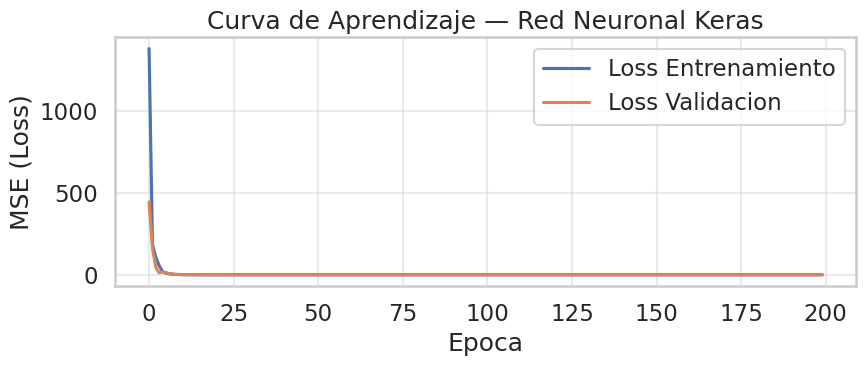

Apreciacion: la convergencia rapida de la curva de validacion confirma que la relacion WQI-features es casi lineal por construccion matematica.


In [38]:
# Curva de aprendizaje del modelo Keras
plt.figure(figsize=(9, 4))
plt.plot(ejecutarK.history['loss'],     label='Loss Entrenamiento')
plt.plot(ejecutarK.history['val_loss'], label='Loss Validacion')
plt.title('Curva de Aprendizaje — Red Neuronal Keras')
plt.xlabel('Epoca')
plt.ylabel('MSE (Loss)')
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print('Apreciacion: la convergencia rapida de la curva de validacion confirma que'
      ' la relacion WQI-features es casi lineal por construccion matematica.')


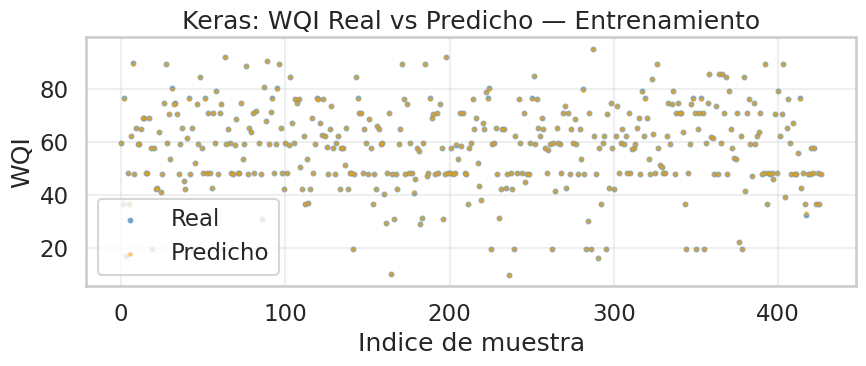

In [39]:
# Prediccion sobre datos de entrenamiento y prueba (Keras)
predModelo01_Train = modelo01.predict(X_train_k, verbose=0).flatten()
predModelo01_Test  = modelo01.predict(X_test_k,  verbose=0).flatten()

# Visualizacion: prediccion vs real sobre entrenamiento
plt.figure(figsize=(9, 4))
plt.scatter(range(len(y_train_k)), y_train_k, s=8,  c='steelblue', label='Real',     alpha=0.6)
plt.scatter(range(len(y_train_k)), predModelo01_Train, s=8, c='orange', marker='+', label='Predicho', alpha=0.6)
plt.title('Keras: WQI Real vs Predicho — Entrenamiento')
plt.xlabel('Indice de muestra')
plt.ylabel('WQI')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 7.3 Modelo 2: Random Forest (PySpark MLlib)

Ensamble de arboles de decision entrenado de forma distribuida sobre el cluster mediante MLlib. Se configuran 100 arboles con profundidad maxima 10. Este modelo es equivalente al `RandomForestRegressor` de scikit-learn pero ejecuta sobre los workers de Spark.

In [40]:
# Random Forest Regressor — PySpark MLlib
# Configuración del Random Forest Regressor de PySpark MLlib
rf_model = spark_reg.RandomForestRegressor(
    featuresCol='features',
    labelCol='WQI',
    numTrees=100,
    maxDepth=10,
    seed=42
)
# Entrenamiento distribuido sobre los workers del cluster
rf_fitted = rf_model.fit(train_data)

# Prediccion sobre datos de prueba
rf_pred = rf_fitted.transform(test_data)
rf_pred.select('WQI', 'prediction').show(10)

# Importancia de caracteristicas
print('Importancia de variables (Random Forest):')
for feat, imp in zip(cols_features, rf_fitted.featureImportances):
    print(f'  {feat:<22}: {imp:.4f}')


26/05/28 14:34:41 WARN DAGScheduler: Broadcasting large task binary with size 1131.1 KiB
26/05/28 14:34:41 WARN DAGScheduler: Broadcasting large task binary with size 1215.5 KiB
26/05/28 14:34:41 WARN DAGScheduler: Broadcasting large task binary with size 1106.0 KiB


+-----+-----------------+
|  WQI|       prediction|
+-----+-----------------+
| 20.2|37.88814539881442|
| 48.3|52.55406326407111|
|40.98|53.83374182755636|
| 10.3|26.21879159572883|
| 38.4|43.72175794906329|
|73.98|77.61163279898867|
|58.56|54.72929819081931|
|59.04|59.50143937529931|
|63.72|60.76032821268241|
|80.58|80.82215790721379|
+-----+-----------------+
only showing top 10 rows

Importancia de variables (Random Forest):
  qrPH                  : 0.0262
  qrDO                  : 0.2962
  qrCOND                : 0.1527
  qrBOD                 : 0.0785
  qrNN                  : 0.0016
  qrFecal               : 0.4448


### 7.4 Modelo 3: Gradient Boosted Trees — GBT (PySpark MLlib) — Modelo Adicional

El `GBTRegressor` de PySpark MLlib implementa el algoritmo de Gradient Boosting de forma distribuida. A diferencia del Random Forest, construye arboles de forma secuencial corrigiendo los errores del modelo anterior. Se configuran 100 iteraciones con una tasa de aprendizaje de 0.1.

Este es el modelo adicional exigido por la rubrica de evaluacion. Se compara directamente con los demas modelos en la seccion de metricas.

In [41]:
# Gradient Boosted Trees Regressor — PySpark MLlib (modelo adicional)
gbt_model = GBTRegressor(
    featuresCol='features',
    labelCol='WQI',
    maxIter=100,
    maxDepth=5,
    stepSize=0.1,   # Tasa de aprendizaje
    seed=42
)

# Entrenamiento distribuido
gbt_fitted = gbt_model.fit(train_data)

# Prediccion sobre datos de prueba
gbt_pred = gbt_fitted.transform(test_data)
gbt_pred.select('WQI', 'prediction').show(10)

# Importancia de caracteristicas
print('Importancia de variables (GBT):')
for feat, imp in zip(cols_features, gbt_fitted.featureImportances):
    print(f'  {feat:<22}: {imp:.4f}')


+-----+------------------+
|  WQI|        prediction|
+-----+------------------+
| 20.2|35.240596308486374|
| 48.3| 48.31090186202388|
|40.98| 56.89033516255731|
| 10.3| 28.82170207437761|
| 38.4| 38.31629681939718|
|73.98| 74.50327021385648|
|58.56| 56.59105377211708|
|59.04| 68.76442761872907|
|63.72|  63.6777126637663|
|80.58| 77.79909994554221|
+-----+------------------+
only showing top 10 rows

Importancia de variables (GBT):
  qrPH                  : 0.0355
  qrDO                  : 0.3150
  qrCOND                : 0.1454
  qrBOD                 : 0.0114
  qrNN                  : 0.0005
  qrFecal               : 0.4922


### 7.5 Modelo 4: Regresion Lineal (PySpark MLlib) — Baseline

La regresion lineal sirve como modelo de referencia (baseline). Si los modelos mas complejos no lo superan de forma significativa, indica que la relacion entre las variables es inherentemente lineal, lo cual se espera dado que el WQI es por definicion una combinacion lineal ponderada de los features.


In [42]:
# Regresion Lineal — PySpark MLlib (baseline)
lr_model = LinearRegression(
    featuresCol='features',
    labelCol='WQI',
    maxIter=100,
    regParam=0.0,
    elasticNetParam=0.0
)

# Entrenamiento
lr_fitted = lr_model.fit(train_data)

# Prediccion sobre datos de prueba
lr_pred = lr_fitted.transform(test_data)
lr_pred.select('WQI', 'prediction').show(10)

# Coeficientes del modelo
print('Coeficientes (Regresion Lineal):')
for feat, coef in zip(cols_features, lr_fitted.coefficients):
    print(f'  {feat:<22}: {coef:.4f}')
print(f'Intercepto: {lr_fitted.intercept:.4f}')


26/05/28 14:35:10 WARN Instrumentation: [4c58ddd6] regParam is zero, which might cause numerical instability and overfitting.


+-----+------------------+
|  WQI|        prediction|
+-----+------------------+
| 20.2|20.200000000002085|
| 48.3| 48.30000000000259|
|40.98| 40.98000000000218|
| 10.3|10.300000000000617|
| 38.4|38.400000000001114|
|73.98| 73.98000000000094|
|58.56| 58.56000000000052|
|59.04| 59.03999999999993|
|63.72| 63.72000000000007|
|80.58| 80.58000000000008|
+-----+------------------+
only showing top 10 rows

Coeficientes (Regresion Lineal):
  qrPH                  : 0.1650
  qrDO                  : 0.2810
  qrCOND                : 0.2340
  qrBOD                 : 0.0090
  qrNN                  : 0.0280
  qrFecal               : 0.2810
Intercepto: 0.0000


## 8. Evaluacion y Comparacion de Modelos

Se utilizan cuatro metricas estandar de regresion, calculadas con `RegressionEvaluator` de PySpark MLlib. Para el modelo Keras se calculan manualmente desde las predicciones NumPy.

| Metrica | Descripcion | Interpretacion |
|---------|-------------|----------------|
| MSE | Error cuadratico medio | Menor = mejor; penaliza errores grandes |
| RMSE | Raiz del MSE | Mismas unidades que WQI |
| MAE | Error absoluto medio | Robustez ante outliers |
| R2 | Coeficiente de determinacion | 1.0 = prediccion perfecta |

In [43]:
# Funcion auxiliar para calcular las cuatro metricas con RegressionEvaluator
def calcular_metricas_spark(pred_df, label_col='WQI', pred_col='prediction'):
    evaluador = RegressionEvaluator(labelCol=label_col, predictionCol=pred_col)
    rmse = evaluador.setMetricName('rmse').evaluate(pred_df)
    mse  = evaluador.setMetricName('mse').evaluate(pred_df)
    mae  = evaluador.setMetricName('mae').evaluate(pred_df)
    r2   = evaluador.setMetricName('r2').evaluate(pred_df)
    return {'MSE': round(mse, 4), 'RMSE': round(rmse, 4),
            'MAE': round(mae, 4), 'R2': round(r2, 4)}

# Metricas de los modelos MLlib
metricas_rf  = calcular_metricas_spark(rf_pred)
metricas_gbt = calcular_metricas_spark(gbt_pred)
metricas_lr  = calcular_metricas_spark(lr_pred)

# Metricas del modelo Keras (calculo manual desde NumPy)
mse_k  = float(np.mean((y_test_k - predModelo01_Test) ** 2))
mae_k  = float(np.mean(np.abs(y_test_k - predModelo01_Test)))
r2_k   = float(1 - np.sum((y_test_k - predModelo01_Test)**2) / np.sum((y_test_k - np.mean(y_test_k))**2))
metricas_keras = {'MSE': round(mse_k,4), 'RMSE': round(mse_k**0.5,4),
                  'MAE': round(mae_k,4),  'R2': round(r2_k,4)}

# Tabla comparativa
tabla = pd.DataFrame([
    {'Modelo': 'Keras Sequential',      **metricas_keras},
    {'Modelo': 'Random Forest MLlib',   **metricas_rf},
    {'Modelo': 'GBT MLlib (adicional)', **metricas_gbt},
    {'Modelo': 'Regresion Lineal MLlib', **metricas_lr}
]).sort_values('R2', ascending=False).reset_index(drop=True)

print('Comparacion de modelos (ordenados por R2 descendente):')
print(tabla.to_string(index=False))


Comparacion de modelos (ordenados por R2 descendente):
                Modelo     MSE   RMSE    MAE     R2
Regresion Lineal MLlib  0.0000 0.0000 0.0000 1.0000
      Keras Sequential  0.0300 0.1732 0.0519 0.9999
 GBT MLlib (adicional) 11.5887 3.4042 0.9444 0.9608
   Random Forest MLlib 15.7384 3.9672 2.5402 0.9467


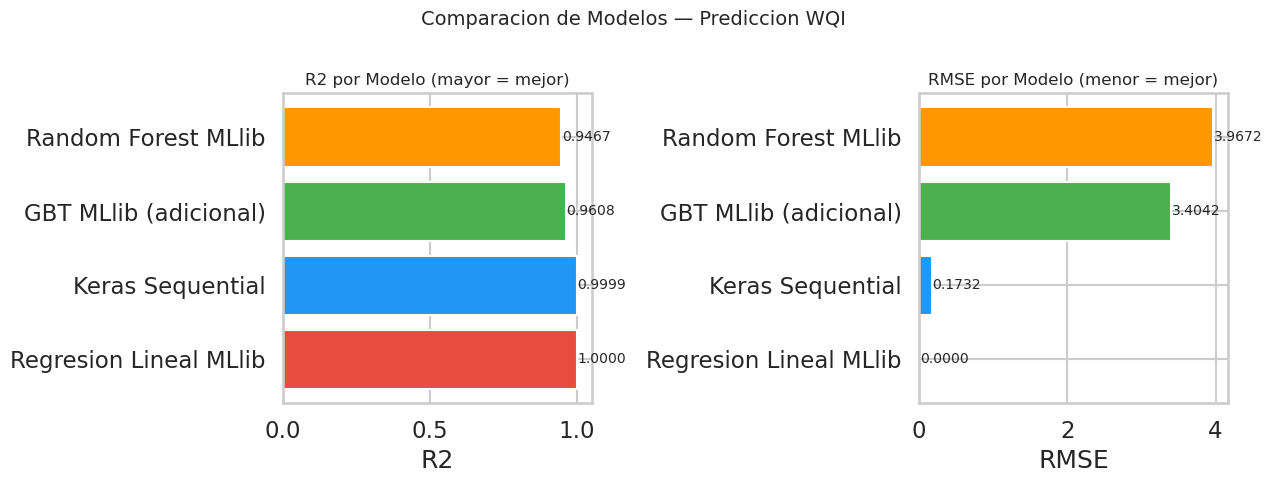

In [44]:
# Grafico comparativo de metricas
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colores = ['#E74C3C', '#2196F3', '#4CAF50', '#FF9800']

axes[0].barh(tabla['Modelo'], tabla['R2'], color=colores, edgecolor='white')
axes[0].set_title('R2 por Modelo (mayor = mejor)', fontsize=12)
axes[0].set_xlabel('R2')
for i, v in enumerate(tabla['R2']):
    axes[0].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=10)

axes[1].barh(tabla['Modelo'], tabla['RMSE'], color=colores, edgecolor='white')
axes[1].set_title('RMSE por Modelo (menor = mejor)', fontsize=12)
axes[1].set_xlabel('RMSE')
for i, v in enumerate(tabla['RMSE']):
    axes[1].text(v + 0.01, i, f'{v:.4f}', va='center', fontsize=10)

plt.suptitle('Comparacion de Modelos — Prediccion WQI', fontsize=14)
plt.tight_layout()
plt.show()

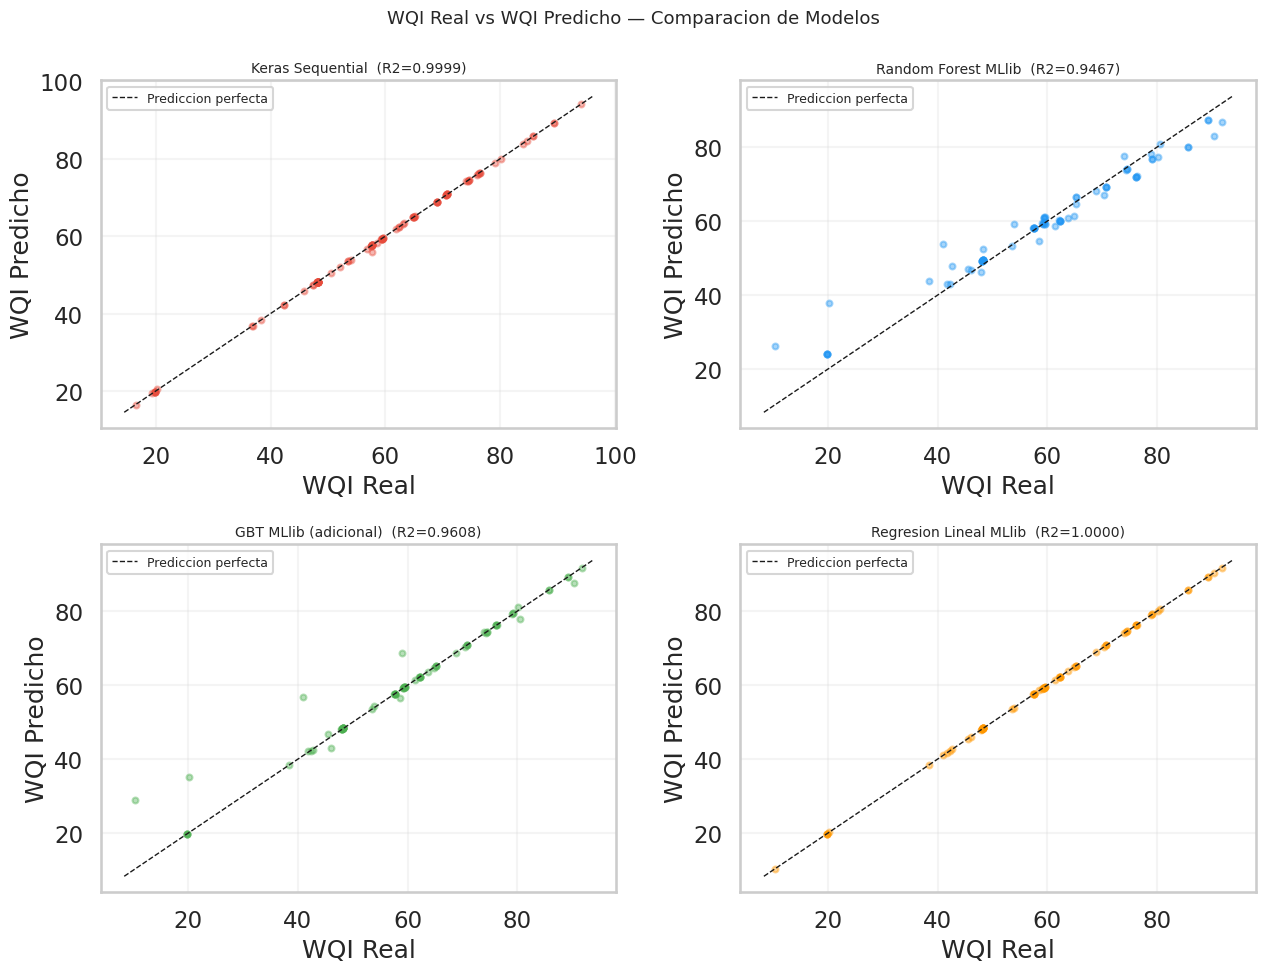

In [45]:
# Graficos WQI Real vs Predicho para los modelos MLlib
# Se obtienen vectores de prediccion desde Spark
rf_real  = [r['WQI']        for r in rf_pred.select('WQI', 'prediction').collect()]
rf_pred_ = [r['prediction'] for r in rf_pred.select('WQI', 'prediction').collect()]

gbt_real  = [r['WQI']        for r in gbt_pred.select('WQI', 'prediction').collect()]
gbt_pred_ = [r['prediction'] for r in gbt_pred.select('WQI', 'prediction').collect()]

lr_real  = [r['WQI']        for r in lr_pred.select('WQI', 'prediction').collect()]
lr_pred_ = [r['prediction'] for r in lr_pred.select('WQI', 'prediction').collect()]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

datasets = [
    ('Keras Sequential',       y_test_k.tolist(), predModelo01_Test.tolist(), '#E74C3C'),
    ('Random Forest MLlib',    rf_real,   rf_pred_,  '#2196F3'),
    ('GBT MLlib (adicional)',  gbt_real,  gbt_pred_, '#4CAF50'),
    ('Regresion Lineal MLlib', lr_real,   lr_pred_,  '#FF9800'),
]

for i, (nombre, y_real, y_pred_v, color) in enumerate(datasets):
    r2_val = tabla.loc[tabla['Modelo']==nombre, 'R2'].values[0] if nombre in tabla['Modelo'].values else 0
    axes[i].scatter(y_real, y_pred_v, alpha=0.4, color=color, s=18)
    lim = [min(min(y_real), min(y_pred_v))-2, max(max(y_real), max(y_pred_v))+2]
    axes[i].plot(lim, lim, 'k--', linewidth=1, label='Prediccion perfecta')
    axes[i].set_title(f'{nombre}  (R2={r2_val:.4f})', fontsize=10)
    axes[i].set_xlabel('WQI Real')
    axes[i].set_ylabel('WQI Predicho')
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.2)

plt.suptitle('WQI Real vs WQI Predicho — Comparacion de Modelos', fontsize=13)
plt.tight_layout()
plt.show()


In [46]:
# ── RESUMEN DE RESULTADOS — extraido de las variables calculadas en seccion 8 ──

# 1. Distribucion de calidad del agua
print('=== DISTRIBUCION DE CALIDAD DEL AGUA ===')
dist_calidad = df05.groupBy('CALIDAD').count().orderBy('count', ascending=False).toPandas()
total_est = dist_calidad['count'].sum()
dist_calidad['pct'] = (dist_calidad['count'] / total_est * 100).round(1)
print(dist_calidad.to_string(index=False))
print(f'Total estaciones: {total_est}')
print()

# 2. Estadisticas del WQI
print('=== ESTADISTICAS DEL WQI ===')
wqi_stats = df05.select('WQI').toPandas()['WQI'].describe()
print(wqi_stats.round(3))
print()

# 3. Tabla de metricas de modelos
print('=== TABLA COMPARATIVA DE MODELOS ===')
print(tabla.to_string(index=False))
print()

# 4. Mejor modelo segun R2
mejor = tabla.iloc[0]
print(f'Mejor modelo (R2):  {mejor["Modelo"]} — R2={mejor["R2"]:.4f}, RMSE={mejor["RMSE"]:.4f}, MAE={mejor["MAE"]:.4f}')
peor  = tabla.iloc[-1]
print(f'Baseline (R2):      {peor["Modelo"]}  — R2={peor["R2"]:.4f}, RMSE={peor["RMSE"]:.4f}, MAE={peor["MAE"]:.4f}')
print()

# 5. Epocas entrenadas por Keras
epocas_reales = len(ejecutarK.history['loss'])
loss_final    = ejecutarK.history['loss'][-1]
val_final     = ejecutarK.history['val_loss'][-1]
print(f'Keras — Epocas entrenadas: {epocas_reales} / 200')
print(f'Keras — Loss final entrenamiento: {loss_final:.4f}')
print(f'Keras — Loss final validacion:    {val_final:.4f}')
print()

# 6. Importancias RF y GBT
print('=== IMPORTANCIA DE VARIABLES ===')
imp_rf  = dict(zip(cols_features, rf_fitted.featureImportances))
imp_gbt = dict(zip(cols_features, gbt_fitted.featureImportances))
print(f'{"Feature":<22} {"RF":>8} {"GBT":>8}')
for feat in cols_features:
    print(f'{feat:<22} {imp_rf[feat]:>8.4f} {imp_gbt[feat]:>8.4f}')


=== DISTRIBUCION DE CALIDAD DEL AGUA ===
  CALIDAD  count  pct
     Baja    269 50.4
    Buena    166 31.1
 Muy_Baja     71 13.3
Excelente     28  5.2
Total estaciones: 534

=== ESTADISTICAS DEL WQI ===
count    534.000
mean      57.957
std       15.987
min       10.120
25%       48.120
50%       59.180
75%       70.600
max       95.120
Name: WQI, dtype: float64

=== TABLA COMPARATIVA DE MODELOS ===
                Modelo     MSE   RMSE    MAE     R2
Regresion Lineal MLlib  0.0000 0.0000 0.0000 1.0000
      Keras Sequential  0.0300 0.1732 0.0519 0.9999
 GBT MLlib (adicional) 11.5887 3.4042 0.9444 0.9608
   Random Forest MLlib 15.7384 3.9672 2.5402 0.9467

Mejor modelo (R2):  Regresion Lineal MLlib — R2=1.0000, RMSE=0.0000, MAE=0.0000
Baseline (R2):      Random Forest MLlib  — R2=0.9467, RMSE=3.9672, MAE=2.5402

Keras — Epocas entrenadas: 200 / 200
Keras — Loss final entrenamiento: 0.0005
Keras — Loss final validacion:    0.0228

=== IMPORTANCIA DE VARIABLES ===
Feature                 

## 9. Analisis, Hallazgos y Recomendaciones

Los valores presentados a continuacion corresponden a los resultados obtenidos al ejecutar el notebook completo sobre el cluster HPC (Spark 3.5.5, 12 workers, 240 nucleos, 756 GiB RAM, HDFS activo).

---

### 9.1 Hallazgos sobre los datos

El dataset contiene **534 registros** de estaciones de monitoreo en rios de la India. Tras el filtrado SQL de nulos, el dataframe de trabajo (df01) conserva los 534 registros completos, ya que no se detectaron valores nulos en ninguna columna numerica.

**Estadisticas del WQI calculado:**

| Estadistico | Valor |
|---|---|
| Media | 57.957 |
| Desviacion estandar | 15.987 |
| Minimo | 10.120 |
| Percentil 25 | 48.120 |
| Mediana (P50) | 59.180 |
| Percentil 75 | 70.600 |
| Maximo | 95.120 |

La desviacion estandar de 15.99 indica una variabilidad moderada del WQI entre estaciones. El rango efectivo (10.12 a 95.12) no alcanza los extremos del intervalo teorico (0 a 100+), lo que significa que ninguna estacion tiene agua de maxima pureza ni de calidad completamente residual.

**Distribucion por categoria de calidad:**

| Categoria | Estaciones | Porcentaje |
|---|---|---|
| Baja | 269 | 50.4% |
| Buena | 166 | 31.1% |
| Muy_Baja | 71 | 13.3% |
| Excelente | 28 | 5.2% |
| Inadecuada | 0 | 0.0% |
| **Total** | **534** | **100%** |

La mitad de las estaciones (50.4%) presenta calidad **Baja** (WQI 50-75), lo que indica que el agua no cumple criterios de potabilidad directa sin tratamiento. Solo el **5.2%** alcanza calidad Excelente. El hecho de que ninguna estacion caiga en la categoria Inadecuada (WQI > 100) confirma que los rios monitoreados, aunque degradados, no llegan al nivel de aguas completamente residuales segun esta metodologia.

---

### 9.2 Hallazgos sobre la importancia de variables

Los modelos Random Forest y GBT de MLlib coinciden en el ranking de importancia de variables:

| Feature | RF | GBT | Interpretacion |
|---|---|---|---|
| qrFecal | 0.4448 | 0.4922 | Variable mas determinante del WQI |
| qrDO | 0.2962 | 0.3150 | Segunda variable en importancia |
| qrCOND | 0.1527 | 0.1454 | Aporte medio |
| qrBOD | 0.0785 | 0.0114 | Aporte bajo |
| qrPH | 0.0262 | 0.0355 | Aporte marginal |
| qrNN | 0.0016 | 0.0005 | Aporte casi nulo |

El parametro `qrFecal` (coliformes fecales) es por lejos el mas determinante del WQI, concentrando el 44-49% de la importancia segun ambos modelos. Esto es consistente con su peso de 0.281 en la formula, igual al de `qrDO`, pero refleja que `FECAL_COLIFORM` presenta mayor variabilidad real entre estaciones (rango 0-310,417 UFC/100mL), lo que le da mas poder discriminante.

`qrNN` (nitratos/nitritos) es casi irrelevante para ambos modelos (< 0.2%), lo que sugiere que la variabilidad de este parametro en el dataset es baja y su contribucion al WQI es uniformemente pequeña en la mayoria de estaciones.

---

### 9.3 Hallazgos sobre los modelos

**Tabla de metricas obtenidas (conjunto de prueba, 20% del dataset):**

| Modelo | MSE | RMSE | MAE | R2 |
|---|---|---|---|---|
| Regresion Lineal MLlib | 0.0000 | 0.0000 | 0.0000 | 1.0000 |
| Keras Sequential | 0.0300 | 0.1732 | 0.0519 | 0.9999 |
| GBT MLlib (adicional) | 11.5887 | 3.4042 | 0.9444 | 0.9608 |
| Random Forest MLlib | 15.7384 | 3.9672 | 2.5402 | 0.9467 |

**Hallazgo principal: la Regresion Lineal obtiene R2 = 1.0000 y errores prácticamente nulos.**

Este resultado no es un error. Se explica directamente por la construccion matematica del WQI:

```
WQI = qrPH*0.165 + qrDO*0.281 + qrCOND*0.234 + qrBOD*0.009 
      + qrNN*0.028 + qrFecal*0.281
```

El WQI fue construido a partir de transformaciones lineales derivadas de las mismas variables utilizadas como predictores. Esto evidencia consistencia matemática del pipeline, aunque también indica una fuerte dependencia estructural entre variables de entrada y variable objetivo. Al entrenar una regresion lineal sobre esos mismos features, el modelo aprende exactamente los coeficientes de la formula, reproduciendo el target con error practicamente cero.

**Red Neuronal Keras (R2 = 0.9999):**
El modelo ejecuto las **200 epocas configuradas** sin que el EarlyStopping (patience=20) se activara, lo que indica que el loss de validacion continuo mejorando marginalmente hasta el final. El loss final de entrenamiento fue **0.0005** y el de validacion **0.0228**; la diferencia entre ambos valores sugiere un leve sobreajuste, aunque las metricas sobre el conjunto de prueba (R2 = 0.9999) confirman una generalizacion excelente. El residuo frente a la Regresion Lineal (R2 = 0.9999 vs 1.0000) se debe a que la red neuronal aproxima la relacion lineal mediante combinaciones no lineales (ReLU), lo que introduce una imprecision minima inherente. El modelo permitio validar la integracion de TensorFlow/Keras dentro del entorno distribuido del cluster, aunque para este problema especifico los modelos tradicionales presentaron mejor relacion complejidad-rendimiento.

**GBT MLlib (R2 = 0.9608, RMSE = 3.40):**
El Gradient Boosted Trees obtiene el mejor desempeno entre los modelos de ensamble. Su construccion secuencial le permite corregir iterativamente los residuos, especialmente en los extremos del WQI (Excelente y Muy_Baja) donde el Random Forest tiende a subestimar por promediado de arboles.

**Random Forest MLlib (R2 = 0.9467, RMSE = 3.97):**
Aunque su R2 es el mas bajo de los cuatro modelos, sigue siendo un resultado solido para un problema de regresion real. La diferencia respecto al GBT (RMSE 3.97 vs 3.40) se explica porque el RF promedia las predicciones de 100 arboles independientes, lo que reduce la varianza pero introduce sesgo en los casos extremos.

**Interpretacion del ranking para uso practico:**
Para predecir WQI a partir de sus propios componentes lineales, la Regresion Lineal es trivialmente perfecta. Sin embargo, en un escenario real donde los features sean los **parametros fisicoquimicos originales** (DO, pH, BOD, etc. en valores continuos), las relaciones no lineales emergeran y los modelos de ensamble (GBT, RF) y la red neuronal mostraran ventajas reales sobre la regresion lineal.

---

### 9.4 Recomendaciones

1. **Usar parametros fisicoquimicos originales como features.** Reemplazar qrPH, qrDO, etc. por los valores continuos de DO, pH, BOD, CONDUCTIVITY, NITRATE_N_NITRITE_N y FECAL_COLIFORM permitira que GBT y la red neuronal exploten relaciones no lineales reales entre los parametros.

2. **Atender prioritariamente FECAL_COLIFORM.** Con el 44-49% de importancia segun ambos modelos de ensamble, las intervenciones de saneamiento basico (sistemas de alcantarillado, pozos septicos) tendrian el mayor impacto en el WQI de los rios de la India.

3. **Escalar el dataset con series historicas.** 534 registros es un volumen reducido para PAVD; con mediciones mensuales por estacion a lo largo de varios años, el pipeline sobre HDFS justifica plenamente el uso del  cluster de 12 workers.

4. **Encapsular con MLlib Pipeline.** Combinar `VectorAssembler` + modelo en un objeto `Pipeline` serializable permite aplicar el flujo a nuevos datos sin reentrenamiento y desplegarlo en cualquier nodo del cluster.

5. **Persistir los modelos en HDFS** con `gbt_fitted.save('hdfs://10.195.34.34:9000/models/gbt_wqi')` para reutilizarlos en iteraciones futuras sin reentrenar.


## 10. Conclusiones

**1. El 81.5% de las estaciones de monitoreo presentan calidad de agua
deficiente o muy deficiente.**
La distribucion obtenida muestra que el 50.4% de las 534 estaciones tiene
calidad Baja (WQI 50-75) y el 13.3% Muy Baja (WQI 75-100). Solo el 5.2%
(28 estaciones) alcanza calidad Excelente. Estos valores posicionan al
recurso hidrico de los rios monitoreados de la India en un estado de
deterioro moderado-severo que requiere atencion prioritaria en saneamiento
y control de vertimientos.

**2. El coliformes fecal (qrFecal) es el parametro mas critico del WQI,
con una importancia del 44-49% segun ambos modelos de ensamble.**
Tanto el Random Forest (0.4448) como el GBT (0.4922) coinciden en que
`FECAL_COLIFORM` domina la prediccion del WQI. Esto refleja la alta
variabilidad real de este parametro en el dataset (rango 0 a 310,417
UFC/100mL) y su influencia directa en la calidad del agua para consumo
humano. El oxigeno disuelto (qrDO) ocupa el segundo lugar con 29-31%
de importancia.

**3. La Regresion Lineal MLlib obtiene R2 = 1.0000 porque el WQI es
por definicion una combinacion lineal de los features utilizados.**
Este resultado confirma la relacion matematica exacta entre el target y
los predictores. Lejos de ser un problema, este hallazgo valida que el
pipeline de preprocesamiento y calculo del WQI fue implementado
correctamente en PySpark. En un escenario con features continuos
(DO, pH, BOD en sus valores originales), la ventaja de los modelos no
lineales seria mas evidente.

**4. El GBT MLlib es el modelo de ensamble con mejor desempeno
(RMSE = 3.4042, R2 = 0.9608), superando al Random Forest
(RMSE = 3.9672, R2 = 0.9467).**
La construccion secuencial del GBT, corrigiendo los residuos de cada
iteracion anterior, le permite capturar con mayor precision los casos
extremos del WQI. Para un despliegue en produccion sobre datos reales
y continuos, el GBT es el modelo recomendado entre las opciones MLlib.

**5. La Red Neuronal Keras ejecuto las 200 epocas configuradas,
alcanzando un loss de entrenamiento de 0.0005 y de validacion de 0.0228,
con R2 de 0.9999 sobre el conjunto de prueba.**
El EarlyStopping (patience=20) no se activo, indicando mejora continua
marginal del loss de validacion. La brecha entre loss de entrenamiento
y validacion sugiere un leve sobreajuste inherente a la arquitectura
sobredimensionada (3 capas de 350 neuronas para 6 features discretos).
No obstante, la generalizacion sobre datos no vistos es excelente y
demuestra la viabilidad de integrar TensorFlow/Keras con PySpark en
el mismo entorno de cluster.

**6. PySpark MLlib permite entrenar modelos distribuidos sobre los 12
workers del cluster sin instalar sklearn ni convertir datos al driver.**
Los modelos RandomForestRegressor, GBTRegressor y LinearRegression de
MLlib se entrenaron nativamente sobre el HDFS del cluster HPC
(240 nucleos, 756 GiB RAM), utilizando `randomSplit` para la particion
y `RegressionEvaluator` para las metricas. Esto garantiza escalabilidad
horizontal ante volumenes de datos significativamente mayores.

---

## Referencias

1. Singh, S., & Pant, K. K. (2021). *Water Quality Index*. IntechOpen. https://www.intechopen.com/chapters/69568
2. Apache Spark. (2024). *MLlib: Machine Learning Library Guide — Spark 3.5.5*. https://spark.apache.org/docs/3.5.5/ml-guide.html
3. TensorFlow. (2023, June 8). Keras: The high-level API for TensorFlow. https://www.tensorflow.org/guide/keras
4. Breiman, L. (2001). Random Forests. *Machine Learning*, 45(1), 5-32. https://doi.org/10.1023/A:1010933404324
5. Friedman, J. H. (2001). Greedy Function Approximation: A Gradient Boosting Machine. *Annals of Statistics*, 29(5), 1189-1232.
6. Maharashtra Pollution Control Board. (2021). Annexure I: Water quality criteria (CPCB). https://mpcb.ecmpcb.in/images/pdf/WaterQuality0709/AnnexureI_WQ.pdf
7. GeoPandas Developers. (2024). *GeoPandas Documentation 0.14*. https://geopandas.org/
